In [242]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder
import math

In [243]:
#!gdown 1EFA6FA5dexDzoj110GKYOtIv_ifReLED

In [244]:
df = pd.read_csv("C:/Users/tienv/OneDrive/Desktop/Nhí/Năm 3/Kì 1/DM/telecom_customer_churn (1).csv")
#df = pd.read_csv("telecom_customer_churn.csv")
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [245]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.head()

,customer_id,gender,age,married,number_of_dependents,city,zip_code,latitude,longitude,number_of_referrals,...,payment_method,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,customer_status,churn_category,churn_reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        7043 non-null   object 
 1   gender                             7043 non-null   object 
 2   age                                7043 non-null   int64  
 3   married                            7043 non-null   object 
 4   number_of_dependents               7043 non-null   int64  
 5   city                               7043 non-null   object 
 6   zip_code                           7043 non-null   int64  
 7   latitude                           7043 non-null   float64
 8   longitude                          7043 non-null   float64
 9   number_of_referrals                7043 non-null   int64  
 10  tenure_in_months                   7043 non-null   int64  
 11  offer                              3166 non-null   objec

In [247]:
df = df.drop(columns=['customer_id'])

In [248]:
df[['city','latitude','longitude']]

,city,latitude,longitude
0,Frazier Park,34.827662,-118.999073
1,Glendale,34.162515,-118.203869
2,Costa Mesa,33.645672,-117.922613
3,Martinez,38.014457,-122.115432
4,Camarillo,34.227846,-119.079903
...,...,...,...
7038,La Mesa,32.759327,-116.997260
7039,Riverbank,37.734971,-120.954271
7040,Elk,39.108252,-123.645121
7041,Solana Beach,33.001813,-117.263628


In [249]:
coords = df[['latitude', 'longitude']].values
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['region_code'] = kmeans.fit_predict(coords)

region_centers = df.groupby('region_code')[['latitude', 'longitude']].mean()
print(region_centers)

region_names = {
    0: 'Northern California',
    1: 'Southern California',
    2: 'Central California',
}

df['region'] = df['region_code'].map(region_names)

df = df.drop(['region_code'], axis=1)

              latitude   longitude
region_code                       
0            37.611400 -121.239425
1            33.912181 -117.792895
2            39.923717 -122.363924


In [250]:
print(df['region'].value_counts())

region
Southern California    3399
Northern California    2513
Central California     1131
Name: count, dtype: int64


Missing values

In [251]:
null = df.isnull().sum()/df.shape[0]*100
null

gender                                0.000000
age                                   0.000000
married                               0.000000
number_of_dependents                  0.000000
city                                  0.000000
zip_code                              0.000000
latitude                              0.000000
longitude                             0.000000
number_of_referrals                   0.000000
tenure_in_months                      0.000000
offer                                55.047565
phone_service                         0.000000
avg_monthly_long_distance_charges     9.683374
multiple_lines                        9.683374
internet_service                      0.000000
internet_type                        21.666903
avg_monthly_gb_download              21.666903
online_security                      21.666903
online_backup                        21.666903
device_protection_plan               21.666903
premium_tech_support                 21.666903
streaming_tv 

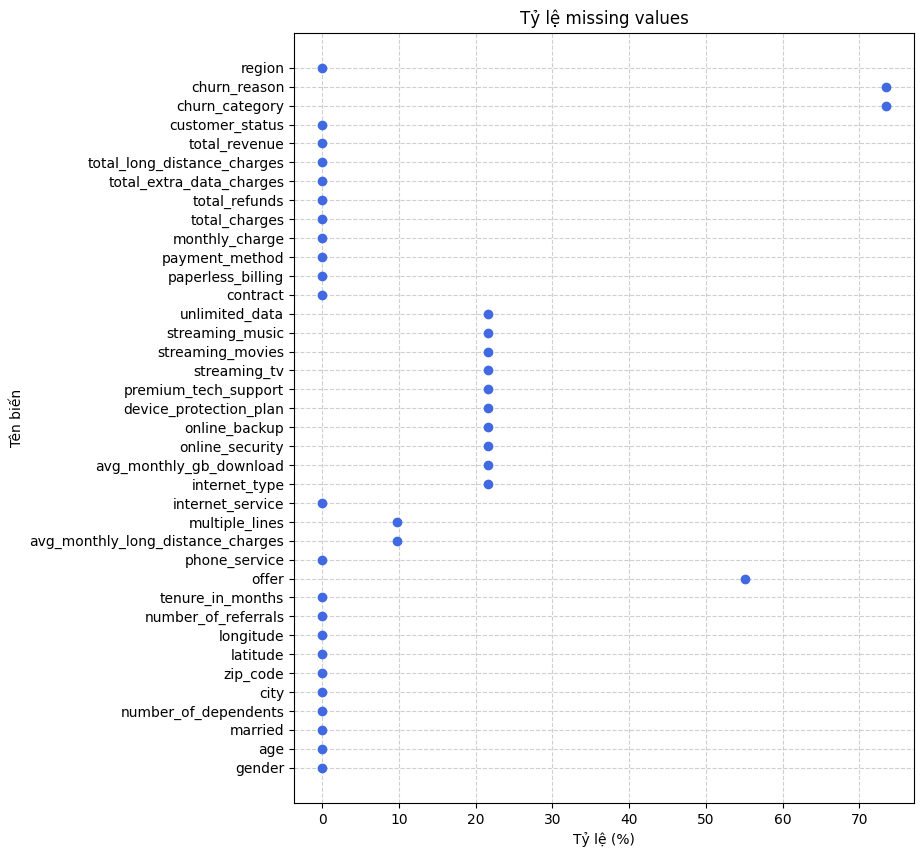

In [252]:
plt.figure(figsize=(8,10))
plt.plot(null.values, null.index, 'o', color='royalblue')
plt.title('Tỷ lệ missing values')
plt.xlabel('Tỷ lệ (%)')
plt.ylabel('Tên biến')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Duplicates

In [253]:
df.duplicated().sum()

0

Phân loại biến

In [254]:
numerical_cols = df.select_dtypes(include=["int","float"]).columns
categorical_cols = df.select_dtypes(include=["object","bool"]).columns

print(f'Số lượng biến định lượng: {len(numerical_cols)}\nGồm các biến: ', numerical_cols)
print(f'\nSố lượng biến định tính: {len(categorical_cols)}\n Gồm các biến: ', categorical_cols)

Số lượng biến định lượng: 15
Gồm các biến:  Index(['age', 'number_of_dependents', 'zip_code', 'latitude', 'longitude',
       'number_of_referrals', 'tenure_in_months',
       'avg_monthly_long_distance_charges', 'avg_monthly_gb_download',
       'monthly_charge', 'total_charges', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue'],
      dtype='object')

Số lượng biến định tính: 23
 Gồm các biến:  Index(['gender', 'married', 'city', 'offer', 'phone_service', 'multiple_lines',
       'internet_service', 'internet_type', 'online_security', 'online_backup',
       'device_protection_plan', 'premium_tech_support', 'streaming_tv',
       'streaming_movies', 'streaming_music', 'unlimited_data', 'contract',
       'paperless_billing', 'payment_method', 'customer_status',
       'churn_category', 'churn_reason', 'region'],
      dtype='object')


Unique

In [255]:
df.nunique()

gender                                  2
age                                    62
married                                 2
number_of_dependents                   10
city                                 1106
zip_code                             1626
latitude                             1626
longitude                            1625
number_of_referrals                    12
tenure_in_months                       72
offer                                   5
phone_service                           2
avg_monthly_long_distance_charges    3583
multiple_lines                          2
internet_service                        2
internet_type                           3
avg_monthly_gb_download                49
online_security                         2
online_backup                           2
device_protection_plan                  2
premium_tech_support                    2
streaming_tv                            2
streaming_movies                        2
streaming_music                   

Thống kê tần suất giá trị của các biến phân loại

In [256]:
for i in df.select_dtypes(include = 'object').columns:
    print(df[i].value_counts())
    print("***"*10)

gender
Male      3555
Female    3488
Name: count, dtype: int64
******************************
married
No     3641
Yes    3402
Name: count, dtype: int64
******************************
city
Los Angeles         293
San Diego           285
San Jose            112
Sacramento          108
San Francisco       104
                   ... 
Johannesburg          2
South Lake Tahoe      2
Jacumba               2
Holtville             2
Eldridge              2
Name: count, Length: 1106, dtype: int64
******************************
offer
Offer B    824
Offer E    805
Offer D    602
Offer A    520
Offer C    415
Name: count, dtype: int64
******************************
phone_service
Yes    6361
No      682
Name: count, dtype: int64
******************************
multiple_lines
No     3390
Yes    2971
Name: count, dtype: int64
******************************
internet_service
Yes    5517
No     1526
Name: count, dtype: int64
******************************
internet_type
Fiber Optic    3035
DSL            1

EDA

In [257]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,7043.0,46.509726,16.750352,19.000000,32.000000,46.000000,60.000000,80.000000
number_of_dependents,7043.0,0.468692,0.962802,0.000000,0.000000,0.000000,0.000000,9.000000
zip_code,7043.0,93486.070567,1856.767505,90001.000000,92101.000000,93518.000000,95329.000000,96150.000000
latitude,7043.0,36.197455,2.468929,32.555828,33.990646,36.205465,38.161321,41.962127
longitude,7043.0,-119.756684,2.154425,-124.301372,-121.788090,-119.595293,-117.969795,-114.192901
number_of_referrals,7043.0,1.951867,3.001199,0.000000,0.000000,0.000000,3.000000,11.000000
tenure_in_months,7043.0,32.386767,24.542061,1.000000,9.000000,29.000000,55.000000,72.000000
avg_monthly_long_distance_charges,6361.0,25.420517,14.200374,1.010000,13.050000,25.690000,37.680000,49.990000
avg_monthly_gb_download,5517.0,26.189958,19.586585,2.000000,13.000000,21.000000,30.000000,85.000000
monthly_charge,7043.0,63.596131,31.204743,-10.000000,30.400000,70.050000,89.750000,118.750000


In [258]:
df.describe(include='object')

,gender,married,city,offer,phone_service,multiple_lines,internet_service,internet_type,online_security,online_backup,...,streaming_movies,streaming_music,unlimited_data,contract,paperless_billing,payment_method,customer_status,churn_category,churn_reason,region
count,7043,7043,7043,3166,7043,6361,7043,5517,5517,5517,...,5517,5517,5517,7043,7043,7043,7043,1869,1869,7043
unique,2,2,1106,5,2,2,2,3,2,2,...,2,2,2,3,2,3,3,5,20,3
top,Male,No,Los Angeles,Offer B,Yes,No,Yes,Fiber Optic,No,No,...,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,Stayed,Competitor,Competitor had better devices,Southern California
freq,3555,3641,293,824,6361,3390,5517,3035,3498,3088,...,2785,3029,4745,3610,4171,3909,4720,841,313,3399


Trực quan phân phối các biến định lượng

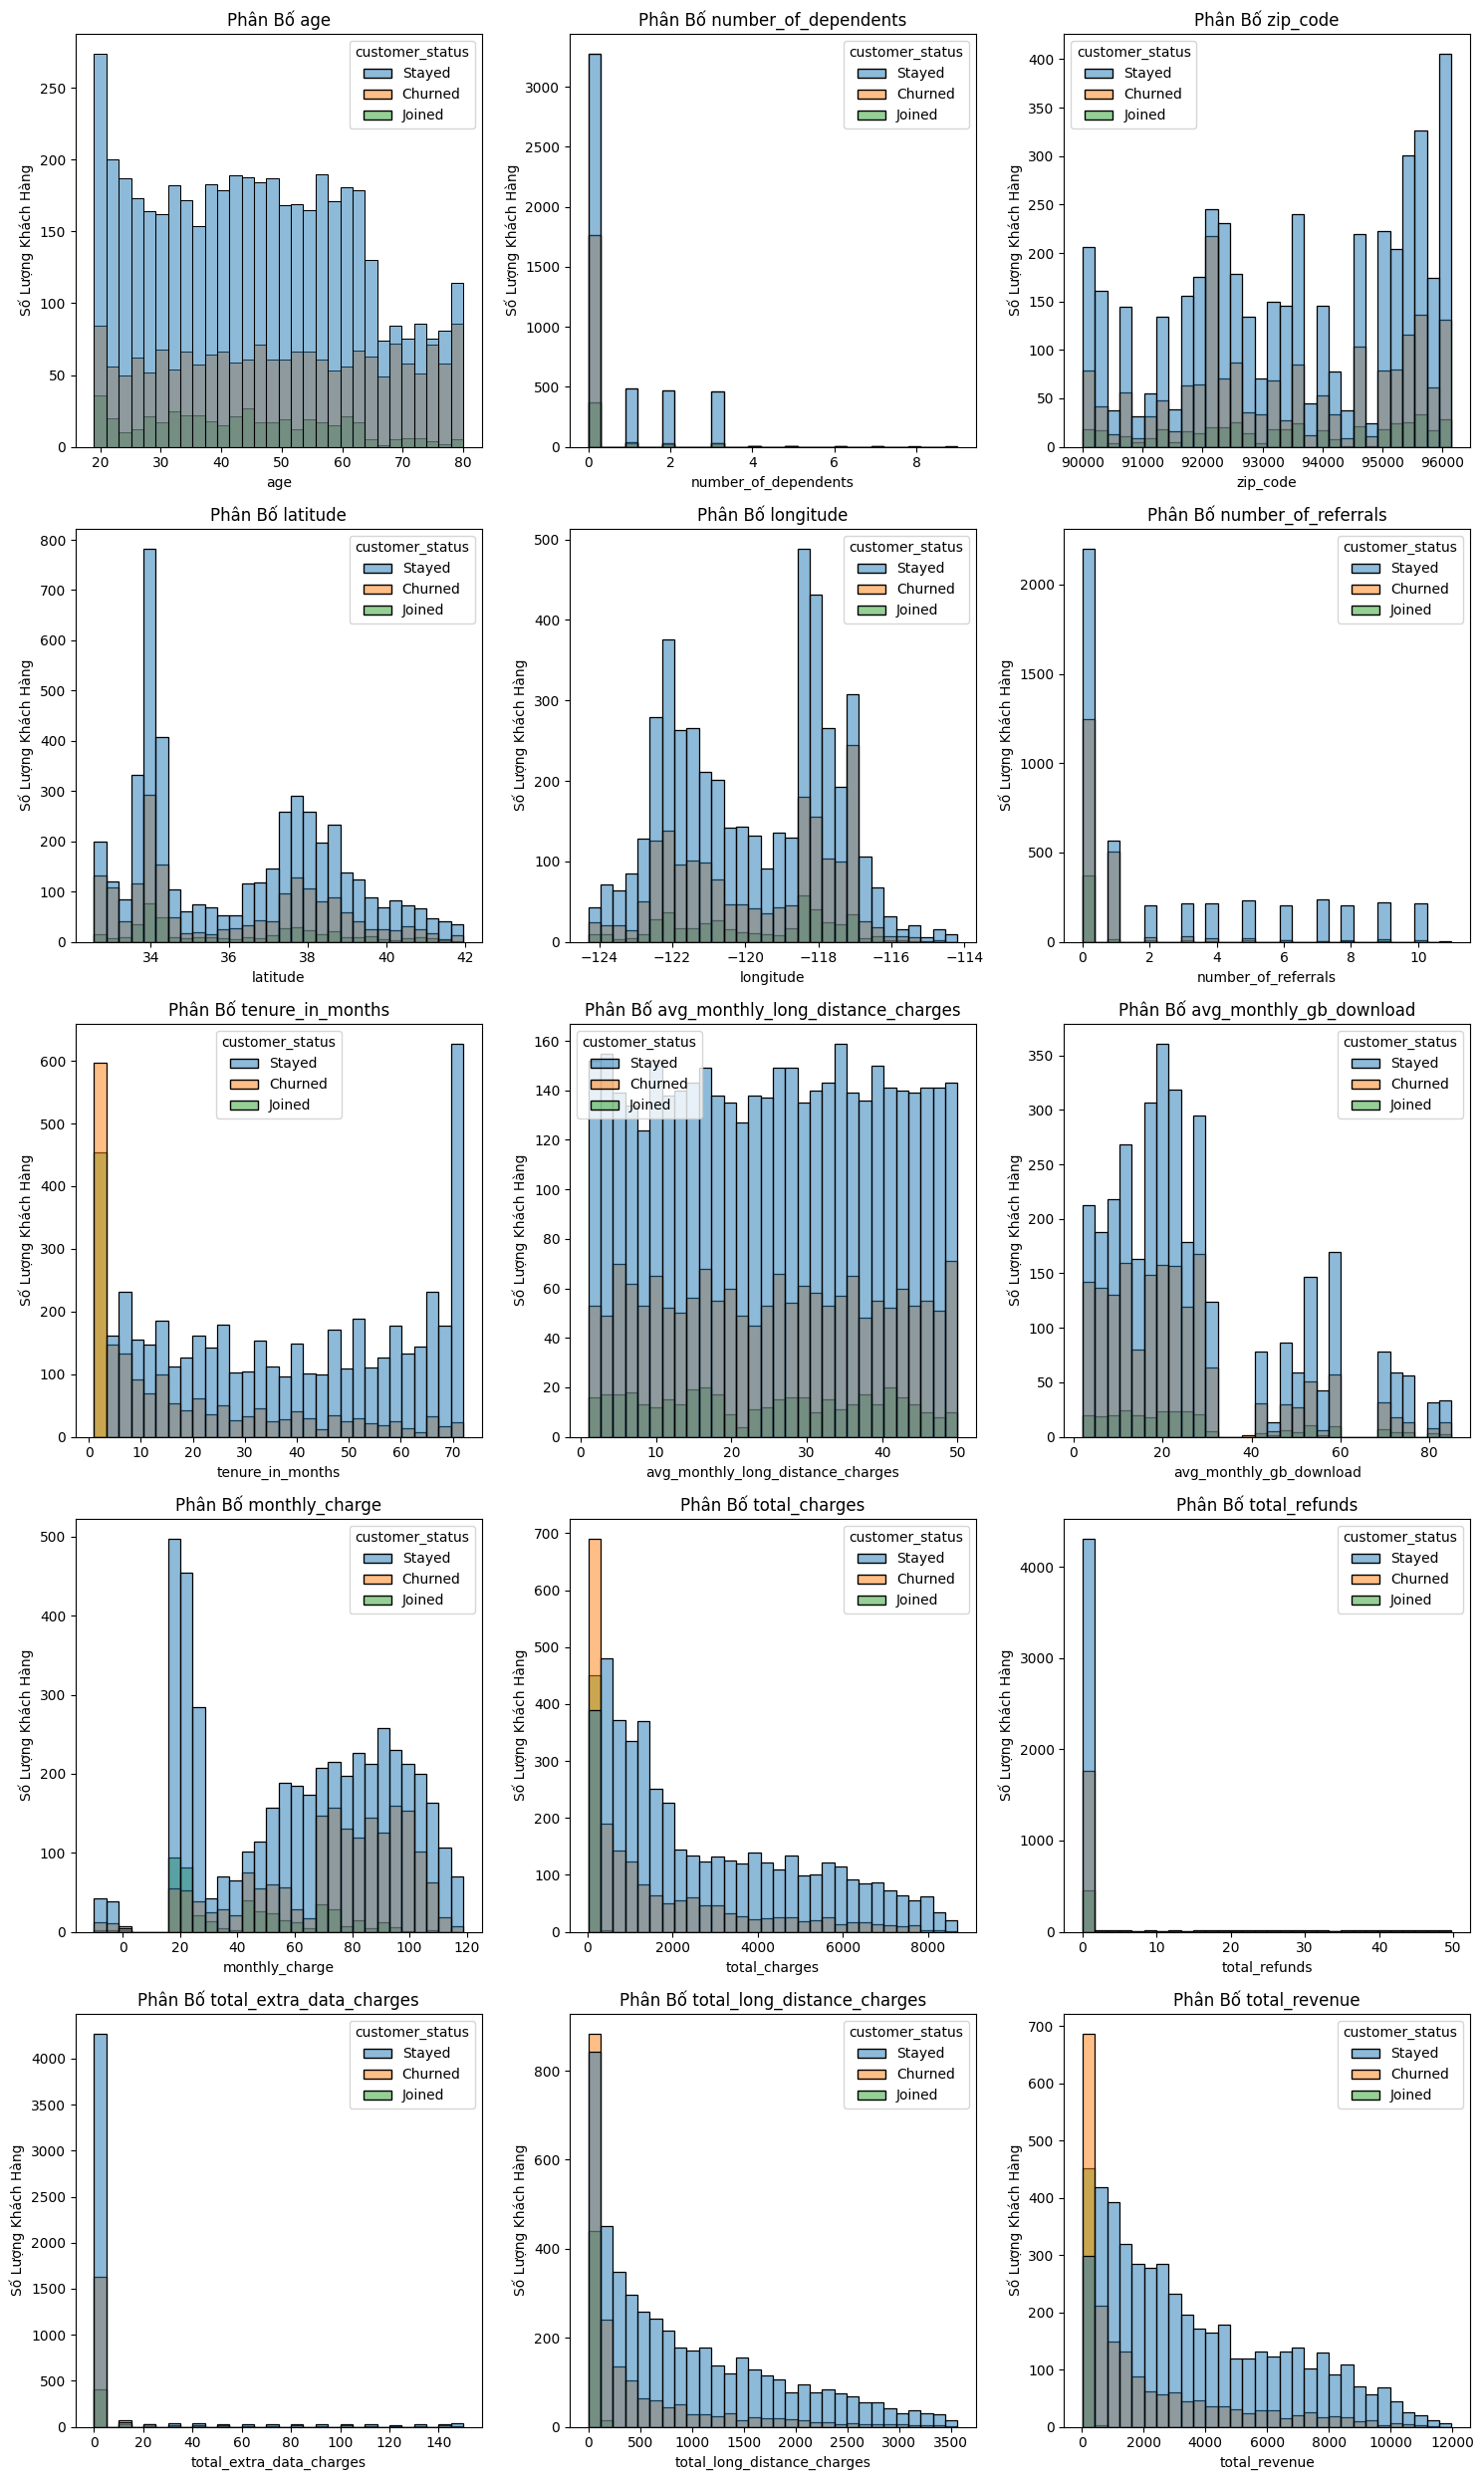

In [259]:
n = len(numerical_cols)
rows = math.ceil(n / 3)
cols = 3


plt.figure(figsize=(15, 5*rows))
for i, col in enumerate(df[numerical_cols]):
    plt.subplot(rows, cols, i+1)
    sbn.histplot(x = df[col], hue=df['customer_status'], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Phân Bố {col}')
    plt.xlabel(col)
    plt.ylabel('Số Lượng Khách Hàng')
    plt.tight_layout()

Trực quan outliers

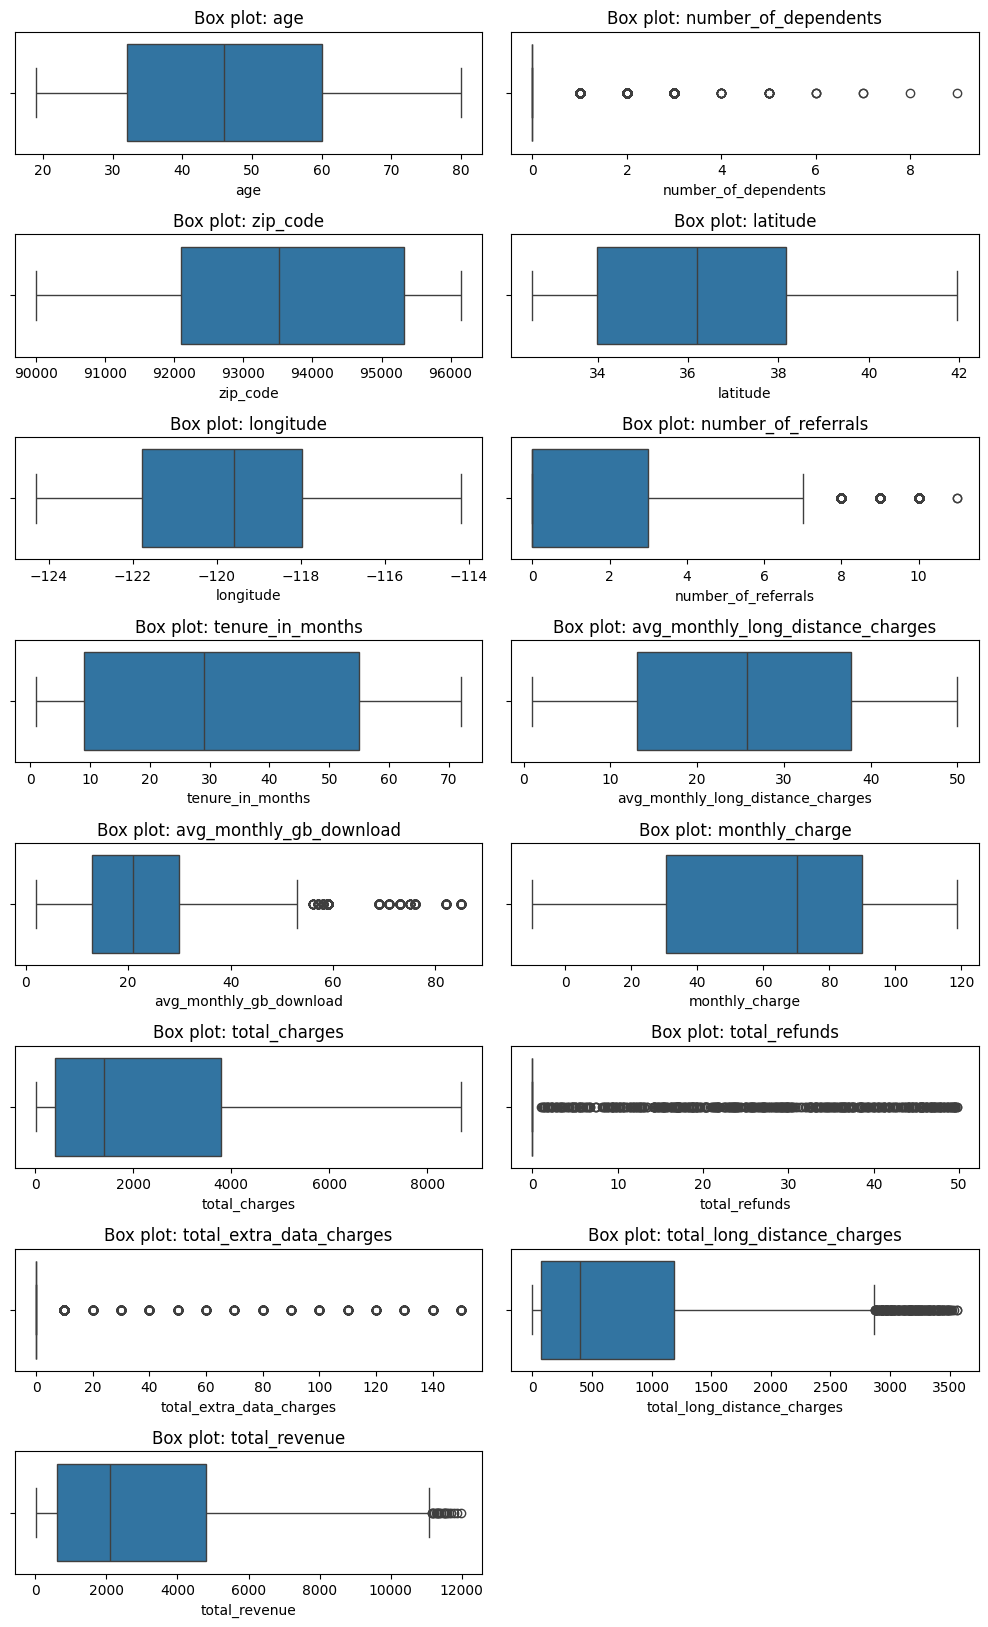

In [260]:
plt.figure(figsize=(10,20))
for i, col in enumerate(df[numerical_cols]):
    plt.subplot(10,2,i+1)
    sbn.boxplot(df[col].dropna(), orient='h')  # bỏ qua giá trị missing
    plt.title(f'Box plot: {col}')
    plt.grid(False)
plt.tight_layout()
plt.show()

Phân tích biến định tính

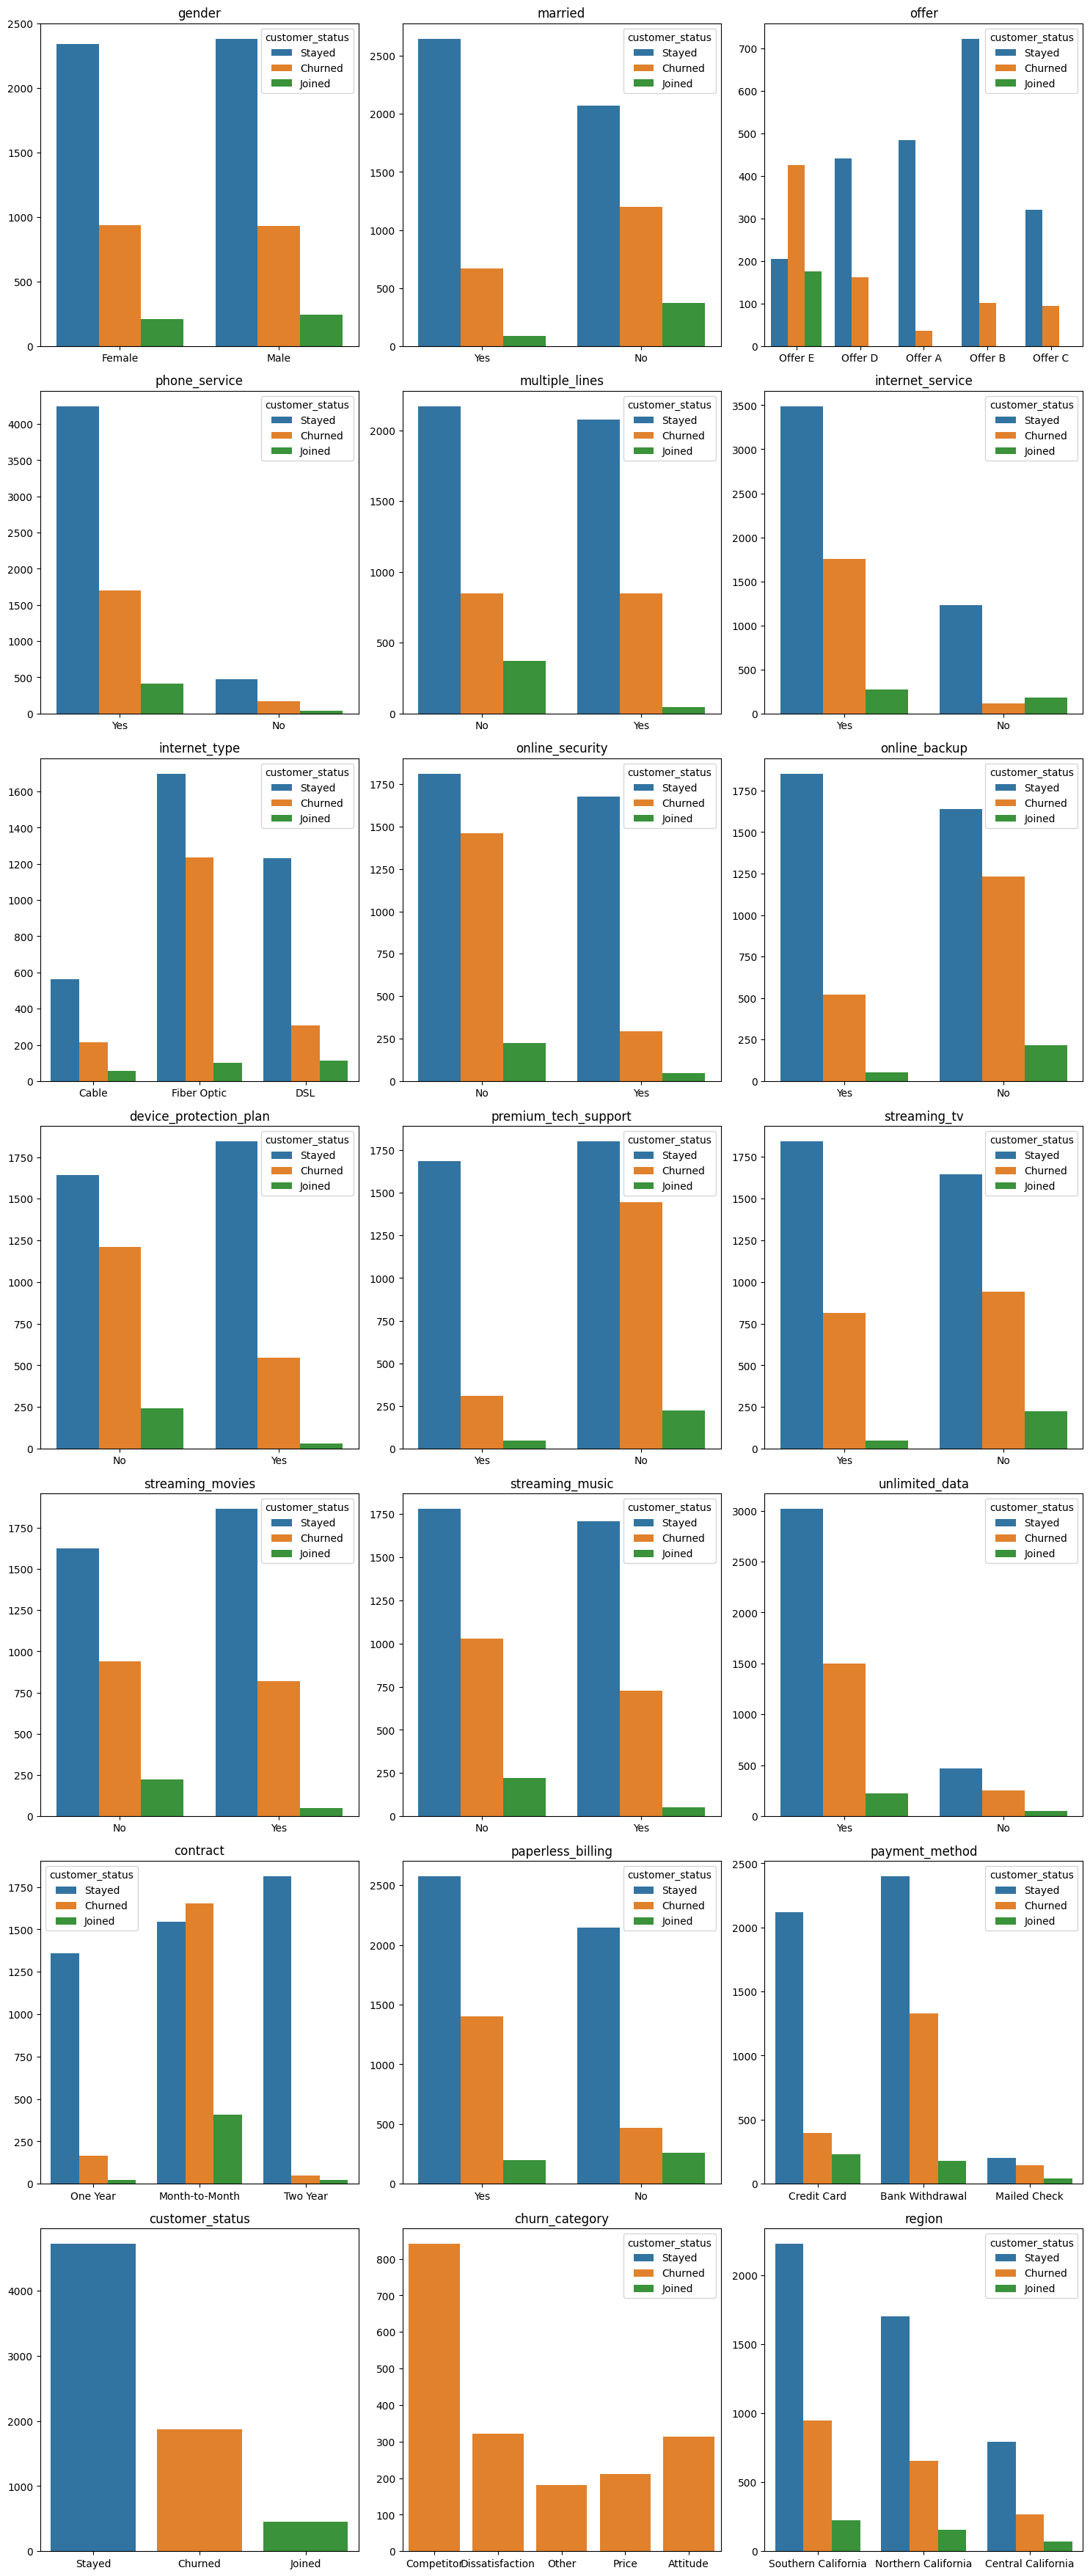

In [261]:
n = len(categorical_cols)
rows = math.ceil(n / 3)
cols = 3

cat = df[categorical_cols].drop(columns=['city', 'churn_reason'])

plt.figure(figsize=(15, 5*rows))
for i, col in enumerate(cat):
    plt.subplot(rows, cols, i+1)
    ax = sbn.countplot(
        data=cat,
        x = col,
        hue='customer_status'
    )

    ax.set(xlabel=None, ylabel=None)
    plt.title(str(col), loc='center')
    plt.xticks(fontsize=10)

plt.tight_layout()
plt.show()

In [262]:
count = df['churn_reason'].value_counts()
count = count.sort_values(ascending=True)

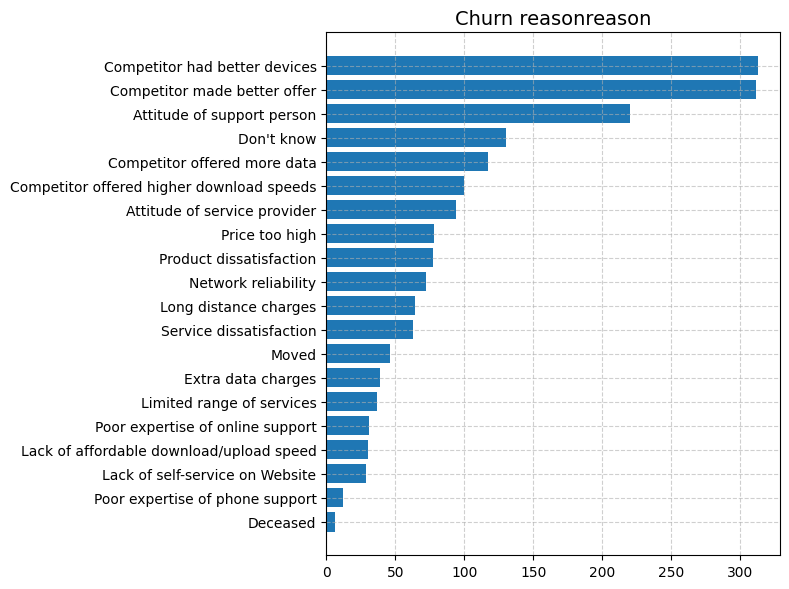

In [263]:
plt.figure(figsize=(8, 6))
plt.barh(count.index, count.values)
plt.title('Churn reasonreason', fontsize=14)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [264]:
count_city = df['city'].value_counts()
top_majors = count_city.nlargest(6)
top_majors = top_majors.sort_values(ascending=False)

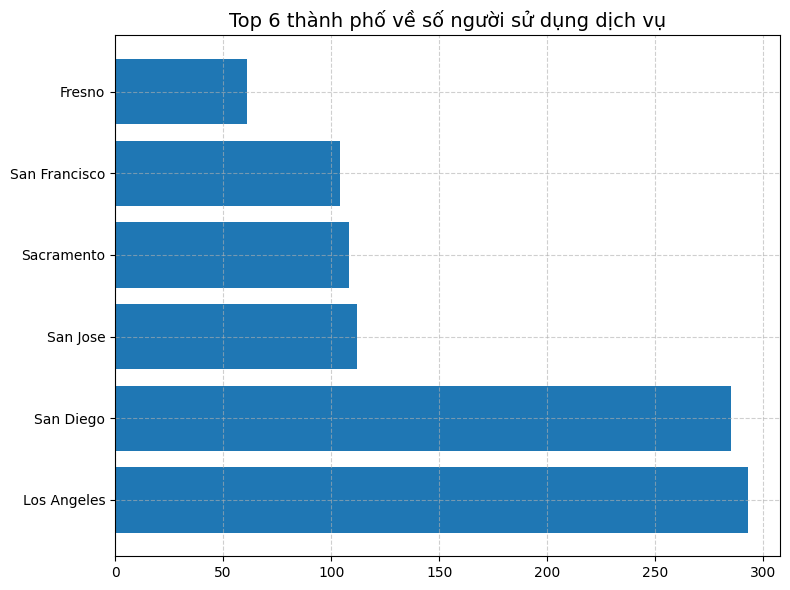

In [265]:
plt.figure(figsize=(8, 6))
plt.barh(top_majors.index, top_majors.values)
plt.title('Top 6 thành phố về số người sử dụng dịch vụ', fontsize=14)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [266]:
corr_matrix = df[numerical_cols].corr()
corr_matrix

,age,number_of_dependents,zip_code,latitude,longitude,number_of_referrals,tenure_in_months,avg_monthly_long_distance_charges,avg_monthly_gb_download,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue
age,1.000000,-0.119000,-0.008183,-0.010305,0.007612,-0.025141,0.009927,-0.020010,-0.566518,0.134511,0.059684,0.024168,0.025036,0.003065,0.048265
number_of_dependents,-0.119000,1.000000,0.016493,0.029081,-0.024271,0.278003,0.108237,-0.002898,0.300802,-0.125649,0.022535,0.014023,-0.014436,0.068966,0.038038
zip_code,-0.008183,0.016493,1.000000,0.894769,-0.790564,0.001463,0.007146,0.012298,-0.002859,-0.002517,0.001978,-0.003797,-0.014550,0.005063,0.002944
latitude,-0.010305,0.029081,0.894769,1.000000,-0.885979,0.018715,0.011963,0.014450,-0.013485,-0.021613,-0.002784,-0.009901,-0.013233,0.008029,0.000082
longitude,0.007612,-0.024271,-0.790564,-0.885979,1.000000,-0.009893,-0.009672,-0.015420,0.015195,0.021052,0.003811,-0.000597,0.010461,-0.006923,0.001062
number_of_referrals,-0.025141,0.278003,0.001463,0.018715,-0.009893,1.000000,0.326975,0.001800,0.080243,0.026301,0.250378,0.024756,0.000350,0.216190,0.261853
tenure_in_months,0.009927,0.108237,0.007146,0.011963,-0.009672,0.326975,1.000000,0.012713,0.038173,0.239065,0.826074,0.059021,0.082266,0.674149,0.853146
avg_monthly_long_distance_charges,-0.020010,-0.002898,0.012298,0.014450,-0.015420,0.001800,0.012713,1.000000,0.019047,0.019149,0.016946,-0.026072,0.021162,0.548759,0.173072
avg_monthly_gb_download,-0.566518,0.300802,-0.002859,-0.013485,0.015195,0.080243,0.038173,0.019047,1.000000,-0.017283,0.031957,-0.011000,0.015451,0.024101,0.031922
monthly_charge,0.134511,-0.125649,-0.002517,-0.021613,0.021052,0.026301,0.239065,0.019149,-0.017283,1.000000,0.622810,0.023963,0.121238,0.235685,0.563249


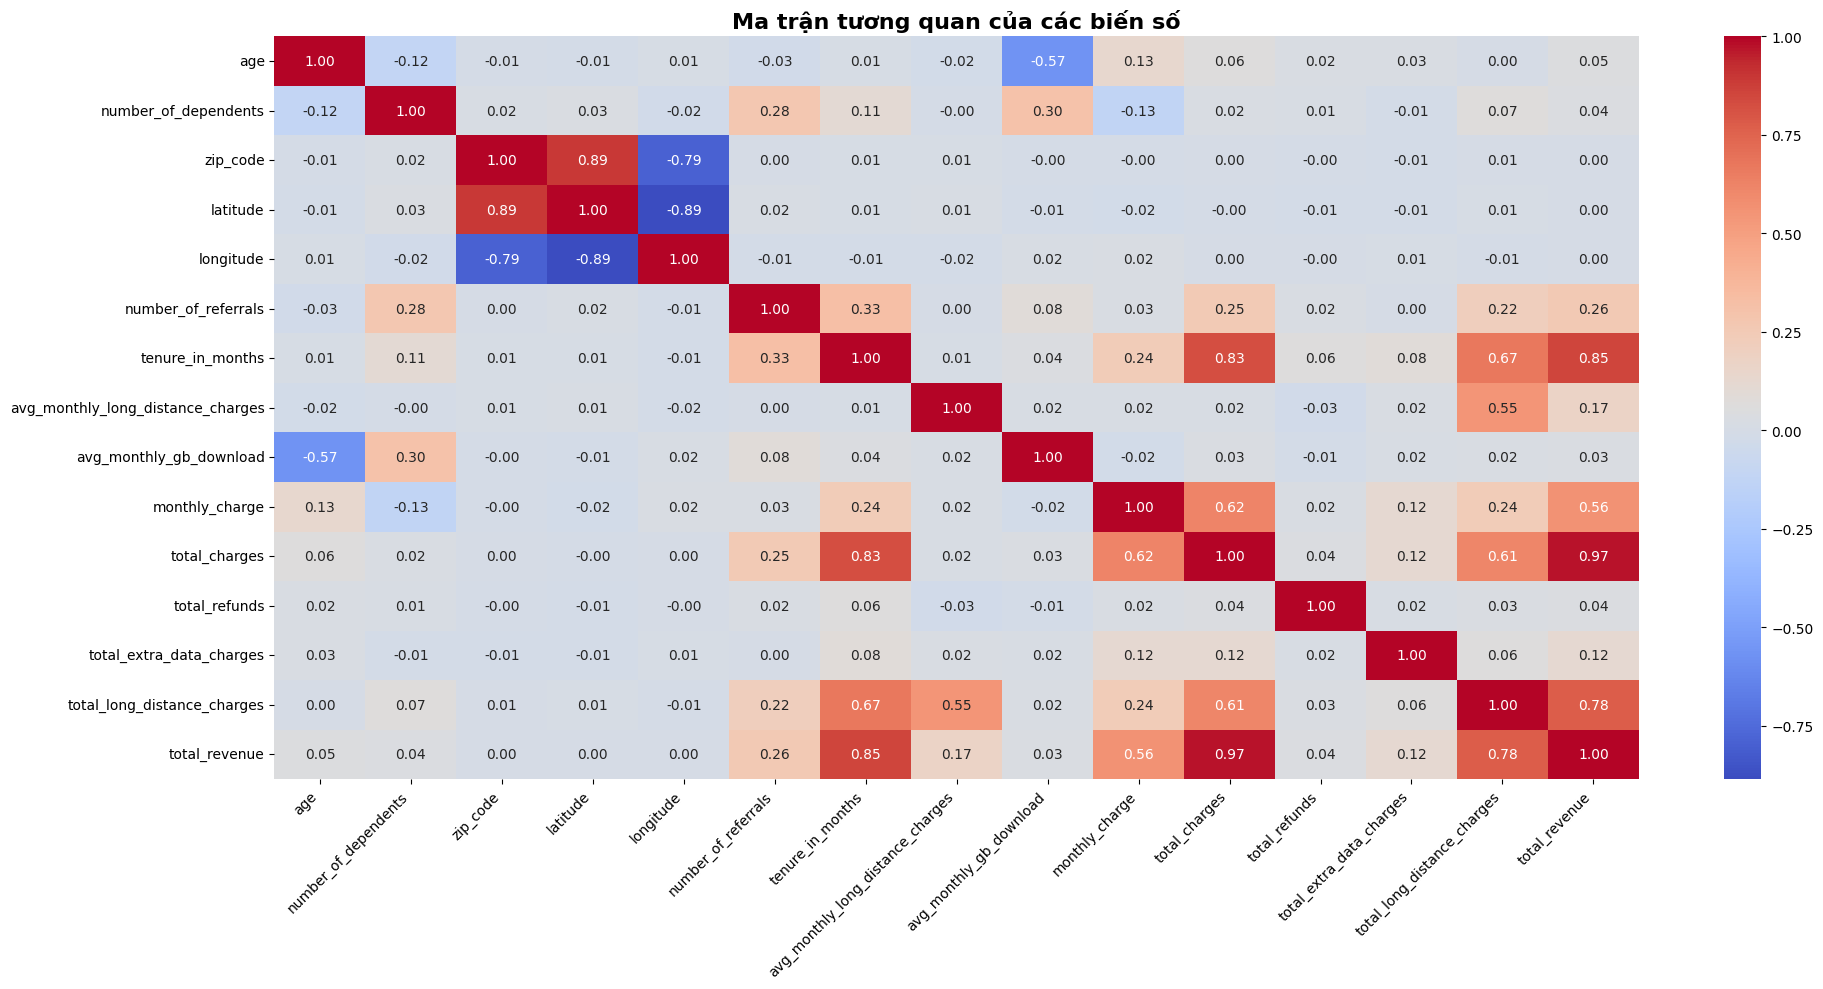

In [267]:
plt.figure(figsize=(20, 10))
sbn.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Ma trận tương quan của các biến số", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [268]:
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs.drop_duplicates().dropna()

high_corr = corr_pairs[corr_pairs > 0.5]
print(high_corr)

age                                age                            1.000000
zip_code                           latitude                       0.894769
tenure_in_months                   total_charges                  0.826074
                                   total_long_distance_charges    0.674149
                                   total_revenue                  0.853146
avg_monthly_long_distance_charges  total_long_distance_charges    0.548759
monthly_charge                     total_charges                  0.622810
                                   total_revenue                  0.563249
total_charges                      total_long_distance_charges    0.610185
                                   total_revenue                  0.972212
total_long_distance_charges        total_revenue                  0.778559
dtype: float64


In [269]:
df.columns

Index(['gender', 'age', 'married', 'number_of_dependents', 'city', 'zip_code',
       'latitude', 'longitude', 'number_of_referrals', 'tenure_in_months',
       'offer', 'phone_service', 'avg_monthly_long_distance_charges',
       'multiple_lines', 'internet_service', 'internet_type',
       'avg_monthly_gb_download', 'online_security', 'online_backup',
       'device_protection_plan', 'premium_tech_support', 'streaming_tv',
       'streaming_movies', 'streaming_music', 'unlimited_data', 'contract',
       'paperless_billing', 'payment_method', 'monthly_charge',
       'total_charges', 'total_refunds', 'total_extra_data_charges',
       'total_long_distance_charges', 'total_revenue', 'customer_status',
       'churn_category', 'churn_reason', 'region'],
      dtype='object')

Cleaning

In [270]:
df = df.drop(columns=['zip_code', 'latitude', 'longitude', 'churn_category', 'churn_reason', 'offer', 'city'])
df = df.reset_index(drop=True)

In [271]:
df.shape

(7043, 31)

In [272]:
#loại bỏ các giá trị Joined trong custommer_status
df = df[df["customer_status"].isin(["Stayed", "Churned"])]
df = df.reset_index(drop=True)

Xử lý missing values

In [273]:
missing_ratio = df.isnull().mean().sort_values(ascending=False)
missing_ratio = missing_ratio[missing_ratio > 0]
print(missing_ratio)

premium_tech_support                 0.203976
avg_monthly_gb_download              0.203976
unlimited_data                       0.203976
streaming_music                      0.203976
streaming_movies                     0.203976
streaming_tv                         0.203976
device_protection_plan               0.203976
online_backup                        0.203976
online_security                      0.203976
internet_type                        0.203976
multiple_lines                       0.097739
avg_monthly_long_distance_charges    0.097739
dtype: float64


In [274]:
df.select_dtypes(include = 'object')

,gender,married,phone_service,multiple_lines,internet_service,internet_type,online_security,online_backup,device_protection_plan,premium_tech_support,streaming_tv,streaming_movies,streaming_music,unlimited_data,contract,paperless_billing,payment_method,customer_status,region
0,Female,Yes,Yes,No,Yes,Cable,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,Stayed,Southern California
1,Male,No,Yes,Yes,Yes,Cable,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,Stayed,Southern California
2,Male,No,Yes,No,Yes,Fiber Optic,No,No,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,Churned,Southern California
3,Male,Yes,Yes,No,Yes,Fiber Optic,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,Churned,Northern California
4,Female,Yes,Yes,No,Yes,Fiber Optic,No,No,No,Yes,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,Churned,Southern California
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6584,Female,No,Yes,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Month-to-Month,No,Bank Withdrawal,Churned,Southern California
6585,Female,No,Yes,No,Yes,DSL,Yes,No,No,Yes,No,No,Yes,Yes,One Year,No,Credit Card,Stayed,Southern California
6586,Male,Yes,Yes,Yes,Yes,Fiber Optic,No,No,No,No,No,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,Churned,Northern California
6587,Male,Yes,Yes,No,Yes,Cable,Yes,No,Yes,Yes,No,Yes,Yes,Yes,Two Year,No,Credit Card,Stayed,Southern California


In [275]:
#dùng median cho numeric
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Internet-related services
internet_features = [
    'online_security', 'online_backup',	'device_protection_plan', 'premium_tech_support',
    'streaming_tv',	'streaming_movies',	'streaming_music',	'unlimited_data'
]

for col in internet_features:
    df.loc[df["internet_service"] == "No", col] = "No"
    df[col] = df[col].fillna("Unknown")

# Phone-related
df.loc[df["phone_service"] == "No", "multiple_lines"] = "No"
df["multiple_lines"] = df["multiple_lines"].fillna("Unknown")

#dùng unknown cho category
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

In [276]:
df.isnull().sum()

gender                               0
age                                  0
married                              0
number_of_dependents                 0
number_of_referrals                  0
tenure_in_months                     0
phone_service                        0
avg_monthly_long_distance_charges    0
multiple_lines                       0
internet_service                     0
internet_type                        0
avg_monthly_gb_download              0
online_security                      0
online_backup                        0
device_protection_plan               0
premium_tech_support                 0
streaming_tv                         0
streaming_movies                     0
streaming_music                      0
unlimited_data                       0
contract                             0
paperless_billing                    0
payment_method                       0
monthly_charge                       0
total_charges                        0
total_refunds            

In [277]:
#xử lí dữ liệu ko nhất quán
col = df.select_dtypes(include = 'object').columns
for c in col:
    print(f'{c}: {df[c].unique()}')

gender: ['Female' 'Male']
married: ['Yes' 'No']
phone_service: ['Yes' 'No']
multiple_lines: ['No' 'Yes']
internet_service: ['Yes' 'No']
internet_type: ['Cable' 'Fiber Optic' 'DSL' 'Unknown']
online_security: ['No' 'Yes']
online_backup: ['Yes' 'No']
device_protection_plan: ['No' 'Yes']
premium_tech_support: ['Yes' 'No']
streaming_tv: ['Yes' 'No']
streaming_movies: ['No' 'Yes']
streaming_music: ['No' 'Yes']
unlimited_data: ['Yes' 'No']
contract: ['One Year' 'Month-to-Month' 'Two Year']
paperless_billing: ['Yes' 'No']
payment_method: ['Credit Card' 'Bank Withdrawal' 'Mailed Check']
customer_status: ['Stayed' 'Churned']
region: ['Southern California' 'Northern California' 'Central California']


In [278]:
# Nếu tenure = 0 → total revenue = 0 
df.loc[df["tenure_in_months"] == 0, "total_revenue"] = 0
#nếu monthly_charge=0 => drop
df = df[df["monthly_charge"] >= 0].reset_index(drop=True)


In [279]:
df.columns

Index(['gender', 'age', 'married', 'number_of_dependents',
       'number_of_referrals', 'tenure_in_months', 'phone_service',
       'avg_monthly_long_distance_charges', 'multiple_lines',
       'internet_service', 'internet_type', 'avg_monthly_gb_download',
       'online_security', 'online_backup', 'device_protection_plan',
       'premium_tech_support', 'streaming_tv', 'streaming_movies',
       'streaming_music', 'unlimited_data', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charge', 'total_charges', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue', 'customer_status', 'region'],
      dtype='object')

Xử lý outliers

In [280]:
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)

handle_out = df[["avg_monthly_gb_download", "total_refunds", "total_extra_data_charges", "total_long_distance_charges"]]
for col in handle_out.columns:
    cap_outliers_iqr(df, col)


# Xử lý các biến:
# avg_monthly_gb_download
# total_refunds
# total_extra_data_charges
# total_long_distance_charges

# Cân nhắc xem xét: number_of_referrals, number_of_referrals

# Không xử lý các biến như: total_revenue

Trực quan lại outliers sau khi xử lý

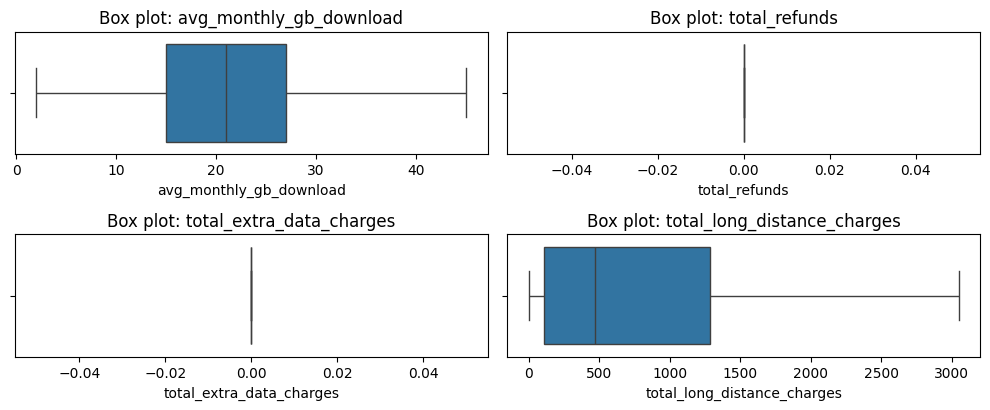

In [281]:
plt.figure(figsize=(10,20))
for i, col in enumerate(handle_out.columns):
    plt.subplot(10,2,i+1)
    sbn.boxplot(df[col].dropna(), orient='h')  # bỏ qua giá trị missing
    plt.title(f'Box plot: {col}')
    plt.grid(False)
plt.tight_layout()
plt.show()

In [282]:
df.shape

(6475, 31)

In [283]:
df.columns

Index(['gender', 'age', 'married', 'number_of_dependents',
       'number_of_referrals', 'tenure_in_months', 'phone_service',
       'avg_monthly_long_distance_charges', 'multiple_lines',
       'internet_service', 'internet_type', 'avg_monthly_gb_download',
       'online_security', 'online_backup', 'device_protection_plan',
       'premium_tech_support', 'streaming_tv', 'streaming_movies',
       'streaming_music', 'unlimited_data', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charge', 'total_charges', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue', 'customer_status', 'region'],
      dtype='object')

In [284]:
#train test split

X = df.drop(columns=["customer_status"])
y = df["customer_status"].map({
    "Stayed": 0,
    "Churned": 1
})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [285]:
#feature engiineering

def add_avg_charge(df): #chi phí tbinh mỗi thág
    df = df.copy()
    df["avg_charge"] = df["total_charges"] / (df["tenure_in_months"] + 1)
    #bỏ biến total_charges
    return df
def add_long_term_flag(df): #khách gắn bó dài hạn
    df = df.copy()
    df["is_long_term"] = (df["tenure_in_months"] >= 12).astype(int)
    return df
def add_tenure_group(df): #phân nhóm KH theo tgian sử dụng DV
    df = df.copy()
    df["tenure_group"] = pd.cut(
        df["tenure_in_months"],
        bins=[0, 6, 12, 24, 72],
        labels=["very_new", "new", "mid", "long"]
    )
    return df

def add_grouped_services(df): #gom các biến
    df = df.copy()

    security_support = [ #bảo mật và hỗ trợ
        'online_security',
        'online_backup',
        'device_protection_plan',
        'premium_tech_support'
    ]

    entertainment = [ #giải trí
        'streaming_tv',
        'streaming_movies',
        'streaming_music'
    ]

    df["num_security_support"] = (df[security_support] == "Yes").sum(axis=1)
    df["num_entertainment"] = (df[entertainment] == "Yes").sum(axis=1)

    # drop biến gốc
    df.drop(columns=security_support + entertainment, inplace=True)

    return df



def feature_engineering(df): #tổng hợp
    df = add_avg_charge(df)
    df = add_long_term_flag(df)
    df = add_tenure_group(df)
    df = add_grouped_services(df)
    return df


X_train = feature_engineering(X_train)
X_test  = feature_engineering(X_test)


X_train = X_train.drop(columns=["total_charges"])
X_test  = X_test.drop(columns=["total_charges"])


In [286]:
#biến binary
binary_cols = [col for col in X_train.columns if X_train[col].nunique() == 2]
binary_cols


['gender',
 'married',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'unlimited_data',
 'paperless_billing',
 'is_long_term']

In [287]:
for col in binary_cols:
    print(col, ":", X_train[col].unique())


gender : ['Male' 'Female']
married : ['Yes' 'No']
phone_service : ['No' 'Yes']
multiple_lines : ['No' 'Yes']
internet_service : ['Yes' 'No']
unlimited_data : ['Yes' 'No']
paperless_billing : ['Yes' 'No']
is_long_term : [1 0]


In [288]:
#encoding
#binary encoding
binary_cols = ['married',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'unlimited_data',
 'paperless_billing'
 ]
X_train[binary_cols] = X_train[binary_cols].replace({"Yes": 1, "No": 0})
X_test[binary_cols]  = X_test[binary_cols].replace({"Yes": 1, "No": 0})

#mã hóa biến gender
X_train["female"] = (X_train["gender"] == "Female").astype(int)
X_test["female"]  = (X_test["gender"] == "Female").astype(int)

X_train.drop(columns=["gender"], inplace=True)
X_test.drop(columns=["gender"], inplace=True)

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# region: one-hot
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
ohe.fit(X_train[["region"]])

region_train = ohe.transform(X_train[["region"]])
region_test  = ohe.transform(X_test[["region"]])

region_cols = ohe.get_feature_names_out(["region"])

# tenure_group: ordinal
ord_enc = OrdinalEncoder(
    categories=[["very_new", "new", "mid", "long"]]
)

X_train["tenure_group_enc"] = ord_enc.fit_transform(X_train[["tenure_group"]])
X_test["tenure_group_enc"]  = ord_enc.transform(X_test[["tenure_group"]])

# drop gốc
X_train.drop(columns=["region", "tenure_group"], inplace=True)
X_test.drop(columns=["region", "tenure_group"], inplace=True)


# concat region
X_train = pd.concat(
    [X_train, pd.DataFrame(region_train, columns=region_cols, index=X_train.index)],
    axis=1
)
X_test = pd.concat(
    [X_test, pd.DataFrame(region_test, columns=region_cols, index=X_test.index)],
    axis=1
)
#one-hot cho mấy biến còn lại
cat_cols = [
    "internet_type",
    "contract",
    "payment_method"
]

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=True)
X_train, X_test = X_train.align(X_test, axis=1, fill_value=0)



In [289]:
bool_cols = X_train.select_dtypes(include="bool").columns

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols]  = X_test[bool_cols].astype(int)


In [290]:
df["customer_status"].value_counts(dropna=False)


customer_status
Stayed     4636
Churned    1839
Name: count, dtype: int64

In [291]:

X_train.columns

Index(['age', 'married', 'number_of_dependents', 'number_of_referrals',
       'tenure_in_months', 'phone_service',
       'avg_monthly_long_distance_charges', 'multiple_lines',
       'internet_service', 'avg_monthly_gb_download', 'unlimited_data',
       'paperless_billing', 'monthly_charge', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue', 'avg_charge', 'is_long_term', 'num_security_support',
       'num_entertainment', 'female', 'tenure_group_enc',
       'region_Northern California', 'region_Southern California',
       'internet_type_DSL', 'internet_type_Fiber Optic',
       'internet_type_Unknown', 'contract_One Year', 'contract_Two Year',
       'payment_method_Credit Card', 'payment_method_Mailed Check'],
      dtype='object')

In [292]:
# SCALING
scale_cols = [
    "age",
    "number_of_dependents",
    "number_of_referrals",
    "tenure_in_months",
    "avg_monthly_long_distance_charges",
    "avg_monthly_gb_download",
    "monthly_charge",
    "avg_charge",
    "total_refunds",
    "total_extra_data_charges",
    "total_long_distance_charges",
    "total_revenue"
]

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])


#IMBALANCE HANDLING
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [293]:
pd.Series(y_train_res).value_counts()


customer_status
0    3709
1    3709
Name: count, dtype: int64

In [294]:
X_train_res_df = pd.DataFrame(
    X_train_res,
    columns=X_train.columns
)
y_train_res_df = y_train_res.reset_index(drop=True).rename("customer_status")

train_preprocessed = pd.concat(
    [X_train_res_df, y_train_res_df],
    axis=1
)
train_preprocessed.to_csv(
    "train_after_preprocessing.csv",
    index=False
)


In [295]:
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBClassifier

# Khởi tạo mô hình XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    colsample_bytree=0.6,
    gamma=0.1,
    reg_alpha=0.1,
    objective="binary:logistic",
    tree_method="hist",
    random_state=2025,
    eval_metric="logloss"
)

# Feature selection dựa trên độ quan trọng của XGBoost
selector = SelectFromModel(
    estimator=xgb,
    threshold="median"   # giữ lại các feature có importance >= median
)

# Fit trên tập train đã xử lý imbalance (SMOTE)
X_train_sel = selector.fit_transform(X_train_res, y_train_res)

# Transform tập test
X_test_sel = selector.transform(X_test)

# Lấy tên các feature được chọn
selected_features = X_train.columns[selector.get_support()]

print("Selected features:")
print(selected_features)



Selected features:
Index(['married', 'number_of_dependents', 'number_of_referrals',
       'tenure_in_months', 'internet_service', 'monthly_charge', 'avg_charge',
       'is_long_term', 'num_security_support', 'num_entertainment',
       'tenure_group_enc', 'internet_type_DSL', 'internet_type_Fiber Optic',
       'contract_One Year', 'contract_Two Year', 'payment_method_Credit Card'],
      dtype='object')


In [296]:

# Lấy feature importance từ RandomForest bên trong selector
importances = selector.estimator_.feature_importances_

# Gắn với tên feature
feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

# Sắp xếp giảm dần
feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance_df)


                              feature  importance
29                  contract_Two Year    0.273987
28                  contract_One Year    0.116964
22                   tenure_group_enc    0.110303
18                       is_long_term    0.066883
30         payment_method_Credit Card    0.058015
3                 number_of_referrals    0.044716
2                number_of_dependents    0.039380
4                    tenure_in_months    0.030450
8                    internet_service    0.027756
26          internet_type_Fiber Optic    0.025577
25                  internet_type_DSL    0.022742
12                     monthly_charge    0.017662
19               num_security_support    0.016640
1                             married    0.014584
20                  num_entertainment    0.013905
17                         avg_charge    0.013756
23         region_Northern California    0.012403
24         region_Southern California    0.012219
0                                 age    0.010559


In [297]:
X_train_sel.shape[1]


16

In [298]:
X_train_sel_df = pd.DataFrame(X_train_sel,columns=selected_features)
X_train_sel_df.to_csv("X_train_processed.csv", index=False)


In [299]:
df_selected = pd.DataFrame(X_train_sel, columns=selected_features)
df_selected["customer_status"] = y_train_res.values
df_selected.to_csv("data_after_feature_selection.csv", index=False)


In [300]:
#X_test

In [301]:
#X_test.to_csv("X_test_preprocessed.csv", index=False)


In [302]:

#X_train_res_df = pd.DataFrame(X_train_res, columns=X_train.columns)
#X_train_res_df.to_csv("X_train_resampled.csv", index=False)
